In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_and_extract_features(filepath):
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            r = json.loads(line)
            
            rho = np.array(r.get('rho', []))
            load = np.array(r.get('load_p', []))
            gen = np.array(r.get('gen_p', []))
            
            if len(rho) == 0: continue
            
            # Forcing strict python scalars (float/int/str) to prevent Pandas hashing errors
            features = {
                'label': str(r['label']),
                'max_rho': float(np.max(rho)),
                'mean_rho': float(np.mean(rho)),
                'std_rho': float(np.std(rho)),
                'rho_above_90_pct': int(np.sum(rho > 0.90)), 
                'rho_above_100_pct': int(np.sum(rho >= 1.0)), 
                'total_load': float(np.sum(load)),
                'total_gen': float(np.sum(gen)),
                'fault_loc': int(r['fault_loc']) if r.get('fault_loc') is not None else -1
            }
            data.append(features)
            
    # Explicitly ensure we return a Pandas DataFrame, not a dict or list
    df = pd.DataFrame(data)
    return df
df = load_and_extract_features("data/grid_dataset_neurips2020.jsonl")

In [2]:
df.head(30)

,label,max_rho,mean_rho,std_rho,rho_above_90_pct,rho_above_100_pct,total_load,total_gen,fault_loc
0,overload,1.016330,0.355553,0.207055,1,1,570.150008,579.660416,2
1,overload,1.014662,0.353938,0.206601,1,1,569.670010,579.109293,2
2,line_trip,0.837616,0.345098,0.201404,0,0,565.680014,574.575830,18
3,line_trip,0.822638,0.340399,0.201853,0,0,561.149988,569.752242,18
4,line_trip,0.819932,0.339049,0.201592,0,0,562.739991,571.358449,18
5,line_trip,0.631360,0.306002,0.166343,0,0,572.679983,581.101034,11
6,line_trip,0.746742,0.306108,0.179315,0,0,576.180003,584.254330,7
7,normal,0.764046,0.305521,0.177272,0,0,573.660010,581.518395,-1
8,normal,0.800037,0.290880,0.175400,0,0,490.270005,495.918006,-1
9,line_trip,0.875145,0.290925,0.189894,0,0,503.859995,509.785530,16


In [3]:
# 1. Verify it's actually a Pandas DataFrame
print(f"Type of df: {type(df)}")

# 2. Verify the columns contain basic data types, not objects/arrays
print(df.dtypes)

# 3. Test the boolean mask manually
mask = (df['label'] == 'normal') & (df['max_rho'] >= 1.0)
print(f"Type of mask: {type(mask)}")

Type of df: <class 'pandas.core.frame.DataFrame'>
label                 object
max_rho              float64
mean_rho             float64
std_rho              float64
rho_above_90_pct       int64
rho_above_100_pct      int64
total_load           float64
total_gen            float64
fault_loc              int64
dtype: object
Type of mask: <class 'pandas.core.series.Series'>


In [4]:
print(df['label'].value_counts())

label
overload     103556
line_trip     75000
normal        61444
cascade       60000
Name: count, dtype: int64


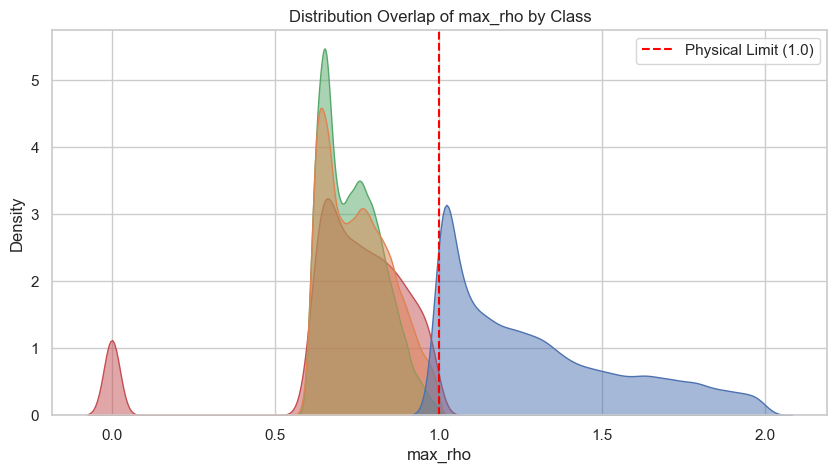

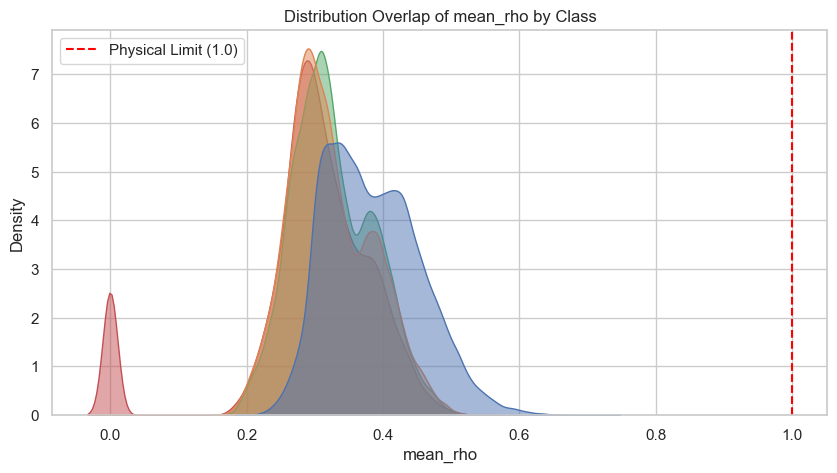

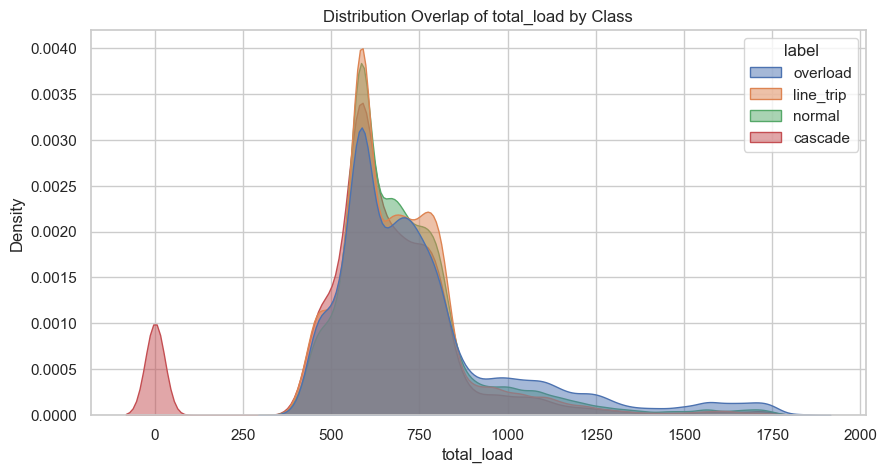

In [5]:
def plot_feature_distributions(df, feature_cols=['max_rho', 'mean_rho', 'total_load']):
    """
    Plots Kernel Density Estimates for given features, colored by label.
    High overlap in these plots explains poor F1 scores.
    """
    sns.set_theme(style="whitegrid")
    
    for feature in feature_cols:
        plt.figure(figsize=(10, 5))
        
        # KDE plot shows the shape of the distribution
        sns.kdeplot(data=df, x=feature, hue='label', common_norm=False, fill=True, alpha=0.5)
        
        plt.title(f'Distribution Overlap of {feature} by Class')
        plt.xlabel(feature)
        plt.ylabel('Density')
        
        # Add a vertical line at 1.0 for rho features to see physical limits
        if 'rho' in feature:
            plt.axvline(x=1.0, color='red', linestyle='--', label='Physical Limit (1.0)')
            plt.legend()
            
        plt.show()

# Usage:
plot_feature_distributions(df)

In [6]:
def find_contradictory_labels_safe(df):
    """
    Safely identifies records where the physical data contradicts the label,
    with protections against missing classes and division by zero.
    """
    print("--- Checking for Contradictory Labels ---")
    
    # Ensure labels are lowercase strings to prevent mismatch errors
    df['label_lower'] = df['label'].astype(str).str.lower()
    
    def check_overlap(label_name, condition, description):
        # Isolate the specific class
        class_df = df[df['label_lower'] == label_name]
        total_class = len(class_df)
        
        # Prevent ZeroDivisionError if the class doesn't exist
        if total_class == 0:
            print(f"[{label_name.upper()}] SKIPPED: 0 records found for this class.")
            return
            
        # Apply the physical condition check
        overlap_df = class_df[condition(class_df)]
        count = len(overlap_df)
        pct = count / total_class
        print(f"[{label_name.upper()}] {description}: {count} out of {total_class} ({pct:.2%})")

    # 1. Normal states that have lines operating at or above 100% capacity
    check_overlap('normal', lambda x: x['max_rho'] >= 1.0, "States with max_rho >= 1.0")
    
    # 2. Line trips that lack high capacity usage (look like normal states)
    # NOTE: Change 'line_trip' here if Step 1 reveals a different spelling!
    check_overlap('line_trip', lambda x: x['max_rho'] < 0.85, "States with max_rho < 0.85") 
    
    # 3. Overload states where no line is actually overloaded
    check_overlap('overload', lambda x: x['max_rho'] < 1.0, "States with max_rho < 1.0")

# Usage:
find_contradictory_labels_safe(df)

--- Checking for Contradictory Labels ---
[NORMAL] States with max_rho >= 1.0: 0 out of 61444 (0.00%)
[LINE_TRIP] States with max_rho < 0.85: 60140 out of 75000 (80.19%)
[OVERLOAD] States with max_rho < 1.0: 0 out of 103556 (0.00%)


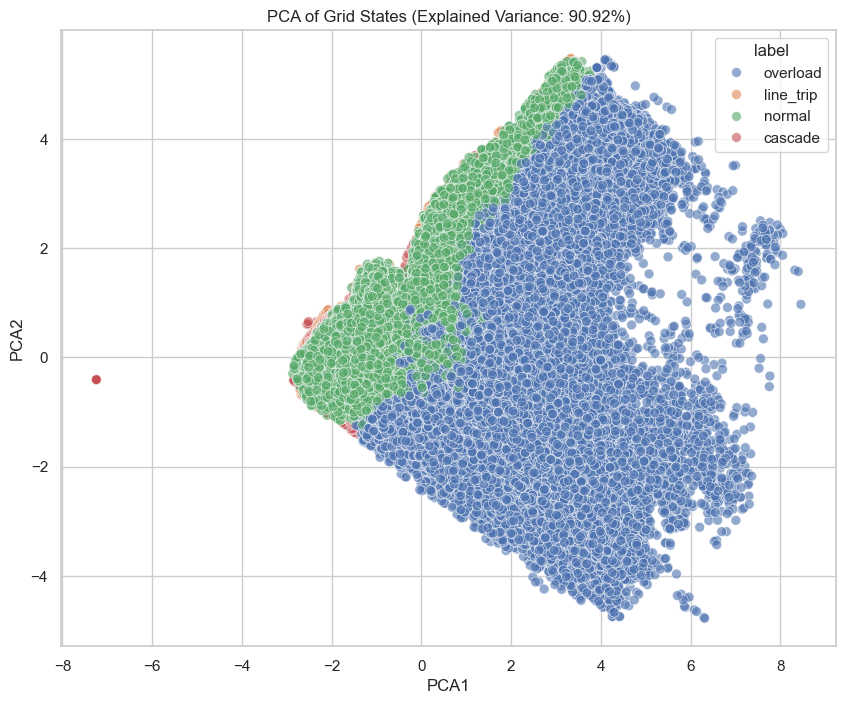

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def plot_pca_clusters(df):
    """
    Projects the features into 2D space to visualize class separability.
    """
    # Select numeric features for clustering
    features = ['max_rho', 'mean_rho', 'std_rho', 'total_load', 'total_gen']
    X = df[features].values
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Apply PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    # Plot
    df_pca = pd.DataFrame({'PCA1': X_pca[:, 0], 'PCA2': X_pca[:, 1], 'label': df['label']})
    
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='label', alpha=0.6, s=50)
    plt.title(f'PCA of Grid States (Explained Variance: {sum(pca.explained_variance_ratio_):.2%})')
    plt.show()

# Usage:
plot_pca_clusters(df)

In [8]:
def analyze_topology_differences(filepath):
    """
    Checks if line_trips actually result in a different number of active edges,
    or if the line_status feature is dead.
    """
    print("--- Topology & Line Status Analysis ---")
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            r = json.loads(line)
            label = str(r.get('label', 'unknown'))
            
            # Assuming 'line_status' or 'connected' might be in the JSON. 
            # Adjust the key based on your actual generate_dataset.py output.
            status = np.array(r.get('line_status', [])) 
            rho = np.array(r.get('rho', []))
            
            if len(rho) == 0: continue
                
            data.append({
                'label': label,
                'total_lines': len(rho),
                'active_lines': int(np.sum(status)) if len(status) > 0 else len(rho),
                'has_disconnected_lines': int(np.sum(status) < len(status)) if len(status) > 0 else 0
            })
            
    topo_df = pd.DataFrame(data)
    
    # See if line_trips actually have fewer active lines
    summary = topo_df.groupby('label').agg(
        avg_total_lines=('total_lines', 'mean'),
        avg_active_lines=('active_lines', 'mean'),
        pct_with_disconnections=('has_disconnected_lines', 'mean')
    )
    
    print(summary)
    return topo_df

# Usage:
topo_df = analyze_topology_differences("data/grid_dataset_neurips2020.jsonl")

--- Topology & Line Status Analysis ---
           avg_total_lines  avg_active_lines  pct_with_disconnections
label                                                                
cascade               59.0         52.709600                 1.000000
line_trip             59.0         58.000000                 1.000000
normal                59.0         59.000000                 0.000000
overload              59.0         57.118574                 0.954875


In [9]:
def check_zero_variance(df):
    """
    Flags any feature that has near-zero variance.
    If a feature doesn't vary, the GNN's weights for it will die.
    """
    print("\n--- Zero Variance Feature Check ---")
    numeric_df = df.select_dtypes(include=[np.number])
    variances = numeric_df.var()
    
    dead_features = variances[variances < 1e-5]
    if len(dead_features) > 0:
        print("WARNING: The following features have effectively zero variance and provide no signal:")
        for feat, var in dead_features.items():
            print(f" - {feat} (Variance: {var:.8f})")
    else:
        print("All numeric features have healthy variance.")

# Usage:
check_zero_variance(df)


--- Zero Variance Feature Check ---
All numeric features have healthy variance.


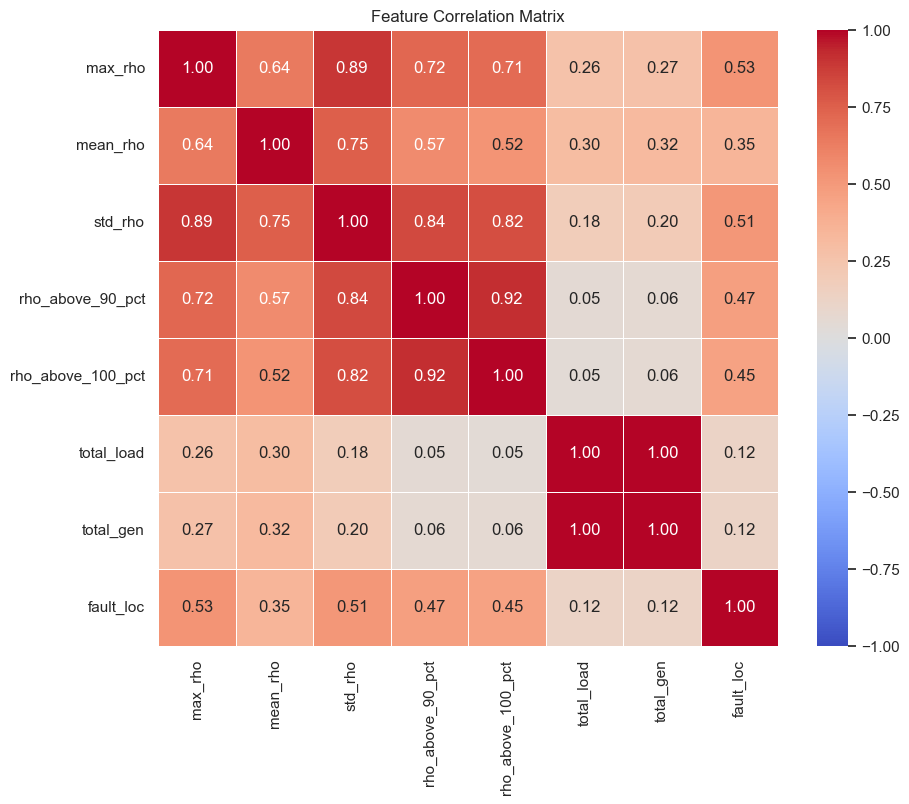

In [10]:
def plot_correlation_heatmap(df):
    """
    Identifies highly redundant features. 
    If two features have > 0.95 correlation, consider dropping one.
    """
    plt.figure(figsize=(10, 8))
    numeric_df = df.select_dtypes(include=[np.number])
    
    # Calculate Pearson correlation matrix
    corr = numeric_df.corr()
    
    # Plot heatmap
    sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
    plt.title("Feature Correlation Matrix")
    plt.show()

# Usage:
plot_correlation_heatmap(df)

In [11]:
def check_node_vs_edge_dropout(filepath):
    """
    Analyzes whether anomalous states drop nodes (substations), 
    edges (lines), or both compared to normal states.
    """
    print("--- Nodes vs. Edges Dropout Analysis ---")
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            r = json.loads(line)
            label = str(r.get('label', 'unknown'))
            
            # Nodes usually represented by load_p or gen_p arrays
            node_count = len(r.get('load_p', []))
            # Edges represented by rho arrays
            edge_count = len(r.get('rho', []))
            
            if node_count == 0 or edge_count == 0: continue
                
            data.append({
                'label': label,
                'node_count': node_count,
                'edge_count': edge_count
            })
            
    df_counts = pd.DataFrame(data)
    
    summary = df_counts.groupby('label').agg(
        avg_nodes=('node_count', 'mean'),
        min_nodes=('node_count', 'min'),
        avg_edges=('edge_count', 'mean'),
        min_edges=('edge_count', 'min')
    )
    print(summary)

# Usage:
check_node_vs_edge_dropout("data/grid_dataset_neurips2020.jsonl")

--- Nodes vs. Edges Dropout Analysis ---
           avg_nodes  min_nodes  avg_edges  min_edges
label                                                
cascade         37.0         37       59.0         59
line_trip       37.0         37       59.0         59
normal          37.0         37       59.0         59
overload        37.0         37       59.0         59



--- Fault Localization Target Bias ---


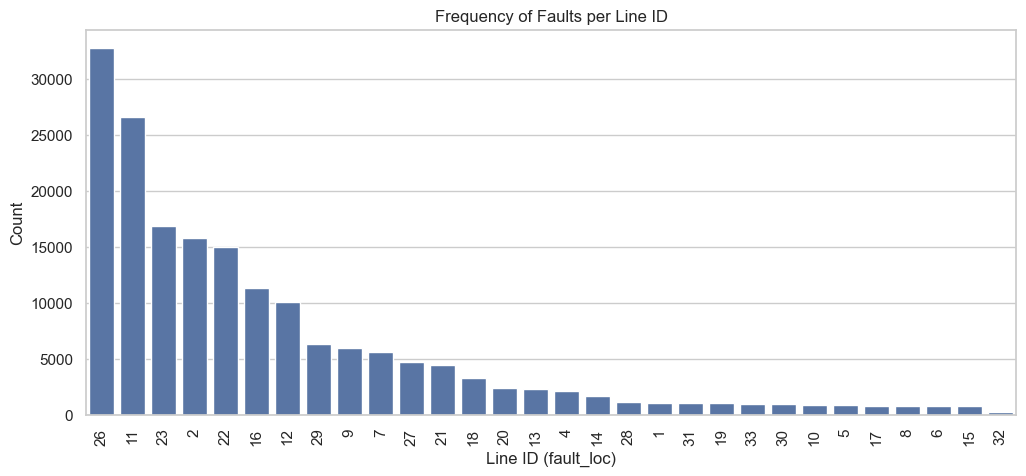

Top 3 most frequently faulted lines:
fault_loc
26    32727
11    26603
23    16885
Name: count, dtype: int64


In [12]:
def check_fault_localization_bias(df):
    """
    Checks if the dataset is heavily biased towards tripping 
    specific lines, which would cause severe overfitting.
    """
    print("\n--- Fault Localization Target Bias ---")
    
    # Filter for states where a specific fault location is logged
    faults = df[df['fault_loc'] >= 0]
    
    if len(faults) == 0:
        print("No localized faults found in dataset.")
        return
        
    plt.figure(figsize=(12, 5))
    sns.countplot(data=faults, x='fault_loc', order=faults['fault_loc'].value_counts().index)
    plt.title('Frequency of Faults per Line ID')
    plt.xlabel('Line ID (fault_loc)')
    plt.ylabel('Count')
    plt.xticks(rotation=90)
    plt.show()
    
    # Print the top 3 most frequently tripped lines
    top_3 = faults['fault_loc'].value_counts().head(3)
    print(f"Top 3 most frequently faulted lines:\n{top_3}")

# Usage (using your existing df):
check_fault_localization_bias(df)


--- Sum Pooling Hypothesis Test ---


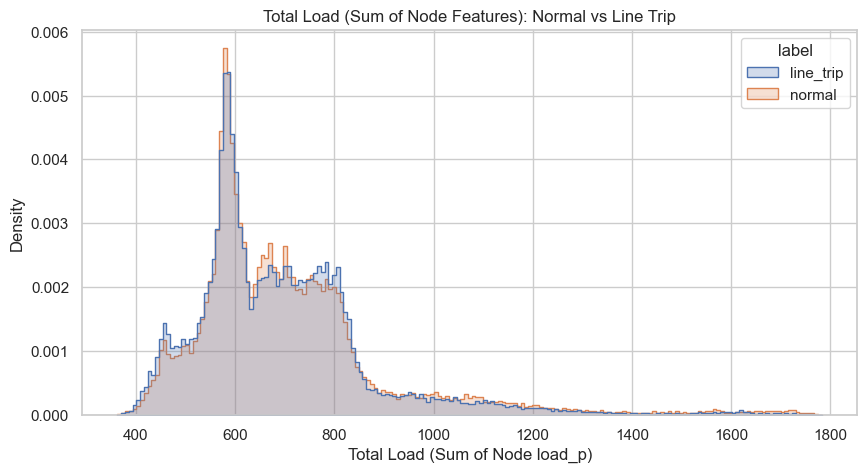

In [13]:
def test_sum_pool_hypothesis(df):
    """
    Calculates if the sum of physical features creates a clean 
    mathematical boundary between normal and line_trip states.
    """
    print("\n--- Sum Pooling Hypothesis Test ---")
    
    # We only care about distinguishing these two for this test
    subset = df[df['label'].isin(['normal', 'line_trip'])]
    
    if len(subset) == 0:
        print("Required labels not found for hypothesis test.")
        return
        
    plt.figure(figsize=(10, 5))
    sns.histplot(data=subset, x='total_load', hue='label', element='step', stat='density', common_norm=False)
    plt.title('Total Load (Sum of Node Features): Normal vs Line Trip')
    plt.xlabel('Total Load (Sum of Node load_p)')
    plt.show()

# Usage (using your existing df):
test_sum_pool_hypothesis(df)